In [1]:
<<FeynCalc`

FeynCalc 10.2.0 (dev version). For help, use the online documentation,
 
>    visit the forum and have a look at the supplied examples.
 
>    The PDF-version of the manual can be downloaded here.
If you use FeynCalc in your research, please evaluate FeynCalcHowToCite[] to\
 
>   learn how to cite this software.
Please keep in mind that the proper academic attribution of our work is\
 
>   crucial to ensure the future development of this package!


In [4]:


(* Prueba de Fuego: Traza de Dirac *)
Calc[Tr[GA[mu, nu, rho, sig]]]

Tr[DiracGamma[LorentzIndex[mu]] . DiracGamma[LorentzIndex[nu]] . 
 
>    DiracGamma[LorentzIndex[rho]] . DiracGamma[LorentzIndex[sig]]]

 RESULTADO DE LA DISPERSIO'N e- mu- -> e- mu- 


FormBox[FractionBox[RowBox[{"8", " ", 

 
>         RowBox[{"(", RowBox[{RowBox[{"2", " ", SuperscriptBox["m", "4"]}], "+", 

 
>             RowBox[{"2", " ", SuperscriptBox["m", "2"], " ", 

 
>               RowBox[{"(", RowBox[{RowBox[{"2", " ", SuperscriptBox["M", "2"]}], 

 
>                   "-", "s", "+", "t", "-", "u"}], ")"}]}], "+", 

 
>             RowBox[{"2", " ", SuperscriptBox["M", "4"]}], "-", 

 
>             RowBox[{"2", " ", SuperscriptBox["M", "2"], " ", 

 
>               RowBox[{"(", RowBox[{"s", "-", "t", "+", "u"}], ")"}]}], "+", 

 
>             SuperscriptBox["s", "2"], "+", SuperscriptBox["u", "2"]}], ")"}]}], 

 
>       SuperscriptBox["t", "2"]], TraditionalForm]
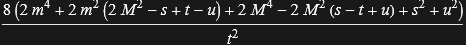

In [39]:
(* 1. Reiniciar el cerebro de Wolfram *)
Clear["Global`*"];

(* ========================================================== *)
(* CONFIGURACIÓN DE FÍSICA AVANZADA: CALIBRADO GENERAL R_xi   *)
(* ========================================================== *)

(* Definimos el propagador del fotón masivo/no-masivo con parámetro xi *)
(* MTD = Métrica D-dimensional, FVD = Vector D-dimensional *)
PropagadorFoton[q_, mu_, nu_, xi_] := 
  -I * FAD[{q, 0}] * ( MTD[mu, nu] - (1 - xi) * FVD[q, mu] * FVD[q, nu] * FAD[{q, 0}] );

(* 2. Definir la Física (Cinemática) *)
FCClearScalarProducts[];
ScalarProduct[p1, p1] = m^2;
ScalarProduct[p3, p3] = m^2;
ScalarProduct[p2, p2] = M^2;
ScalarProduct[p4, p4] = M^2;

(* Definimos el momento transferido q *)
ScalarProduct[p1, p3] = m^2 - t/2;
ScalarProduct[p2, p4] = M^2 - t/2;

(* 3. Escribir la Amplitud *)
(* Usamos SpinorU para asegurar que son partículas *)
amp = (SpinorUBar[p3, m] . GA[mu] . SpinorU[p1, m]) * (MetricTensor[mu, nu] / t) * (SpinorUBar[p4, M] . GA[nu] . SpinorU[p2, M]);

(* 4. CALCULAR EL CUADRADO (Paso Crítico) *)
(* ComplexConjugate[amp] * amp nos da |M|^2 *)
sqAmp = ComplexConjugate[amp] * amp;

(* 5. FORZAR LA TRAZA (Aquí es donde fallaba antes) *)
(* FermionSpinSum: Convierte espinores en Trazas *)
(* DiracSimplify: Resuelve las Trazas matemáticamente *)
traceResult = sqAmp // FermionSpinSum // DiracSimplify // Contract;

(* 6. Sustituir variables de Mandelstam *)
mandelstamRules = {
   ScalarProduct[p1, p2] -> (s - m^2 - M^2)/2,
   ScalarProduct[p3, p4] -> (s - m^2 - M^2)/2,
   ScalarProduct[p1, p4] -> (m^2 + M^2 - u)/2,
   ScalarProduct[p3, p2] -> (m^2 + M^2 - u)/2
};

(* 7. RESULTADO FINAL *)
finalResult = traceResult /. mandelstamRules // Simplify;

Print["==============================================="];
Print[" RESULTADO DE LA DISPERSIÓN e- mu- -> e- mu- "];
Print["==============================================="];
TraditionalForm[finalResult]

# a Autoenergía del Electrón a 1-loop $\Sigma(p)$. 

 AUTOENERGI'A DEL ELECTRO'N A 1-LOOP 
Resultado Completo (Finito + Divergente):
Parte Divergente (Polo UV para Renormalizar):


FormBox[FractionBox[RowBox[{"", " ", SuperscriptBox["π", "2"], " ", 

 
>         SuperscriptBox["e", "2"], " ", 

 
>         RowBox[{"(", RowBox[{RowBox[{FormBox[TagBox[FormBox[RowBox[

 
>                   {SubscriptBox["\"B\"", "\"0\""], "(", 

 
>                    RowBox[{SuperscriptBox[FormBox[OverscriptBox[

 
>                         FormBox["p", TraditionalForm], "_"], TraditionalForm], 

 
>                       2], ",", "0", ",", SuperscriptBox["m", "2"]}], ")"}], 

 
>                  TraditionalForm], HoldForm], TraditionalForm], " ", 

 
>               RowBox[{"(", RowBox[{RowBox[{RowBox[{OverscriptBox["γ", "_"], "·", 

 
>                       FormBox[OverscriptBox[FormBox["p", TraditionalForm], "_"], 

 
>                        TraditionalForm]}], " ", 

 
>                     RowBox[{"(", RowBox[{RowBox[{SuperscriptBox[FormBox[

 
>                             OverscriptBox[FormBox["p", TraditionalForm], "_"], 

 
>                             TraditionalForm], 2], " ", 

 
>                           RowBox[{"(", 

 
>                             RowBox[{"D", "+", RowBox[{"2", " ", "xi"}], "-", 

 
>                              "4"}], ")"}]}], "+", 

 
>                         RowBox[{RowBox[{"(", RowBox[{"D", "-", "2"}], ")"}], " ", 

 
>                           SuperscriptBox["m", "2"]}]}], ")"}]}], "-", 

 
>                   RowBox[{"2", " ", "m", " ", 

 
>                     SuperscriptBox[FormBox[OverscriptBox[FormBox["p", 

 
>                         TraditionalForm], "_"], TraditionalForm], 2], " ", 

 
>                     RowBox[{"(", RowBox[{"D", "+", "xi", "-", "1"}], ")"}]}]}],\
 
>    ")"}]}\
], "-", RowBox[{"2", " ", RowBox[{"(", RowBox[{"xi", "-", "1"}], ")"}], "\
 
>    ", 
            SuperscriptBox[FormBox[OverscriptBox[FormBox["p", TraditionalForm],\
 
>    
               "_"], TraditionalForm], 2], " ", 

 
>               RowBox[{"(", RowBox[{SuperscriptBox["m", "2"], "-", 

 
>                   SuperscriptBox[FormBox[OverscriptBox[FormBox["p", 

 
>                       TraditionalForm], "_"], TraditionalForm], 2]}], ")"}], " ", 

 
>               RowBox[{OverscriptBox["γ", "_"], "·", 

 
>                 FormBox[OverscriptBox[FormBox["p", TraditionalForm], "_"], 

 
>                  TraditionalForm]}], " ", 

 
>               FormBox[RowBox[{SubscriptBox["\"C\"", "\"1\""], "(", 

 
>                  RowBox[{SuperscriptBox[FormBox[OverscriptBox[FormBox["p", 

 
>                        TraditionalForm], "_"], TraditionalForm], 2], ",", 

 
>                    SuperscriptBox[FormBox[OverscriptBox[FormBox["p", 

 
>                        TraditionalForm], "_"], TraditionalForm], 2], ",", "0", ",", 

 
>                    "0", ",", SuperscriptBox["m", "2"], ",", "0"}], ")"}], 

 
>                TraditionalForm]}], "-", 

 
>             RowBox[{RowBox[{"(", RowBox[{RowBox[{"(", RowBox[{"D", "-", "2"}], ")"}], 

 
>                   " ", FormBox[TagBox[FormBox[RowBox[{SubscriptBox["\"A\"", 

 
>                         "\"0\""], "(", SuperscriptBox["m", "2"], ")"}], 

 
>                      TraditionalForm], HoldForm], TraditionalForm], " ", 

 
>                   RowBox[{OverscriptBox["γ", "_"], "·", 

 
>                     FormBox[OverscriptBox[FormBox["p", TraditionalForm], "_"], 

 
>                      TraditionalForm]}]}], ")"}]}]}], ")"}]}], 

 
>       RowBox[{"2", " ", SuperscriptBox[FormBox[OverscriptBox[FormBox["p", 

 
>             TraditionalForm], "_"], TraditionalForm], 2]}]], TraditionalForm]

FormBox[FractionBox[RowBox[{"2", " ", "", " ", SuperscriptBox["π", "2"], " ", 

 
>         SuperscriptBox["e", "2"], " ", 
      RowBox[{"(", RowBox[{RowBox[{"m", " ", 

 
>               RowBox[{"(", RowBox[{"xi", "+", "3"}], ")"}]}], "-", 

 
>             RowBox[{"xi", " ", RowBox[{OverscriptBox["γ", "_"], "·", 

 
>                 FormBox[OverscriptBox[FormBox["p", TraditionalForm], "_"], 

 
>                  TraditionalForm]}]
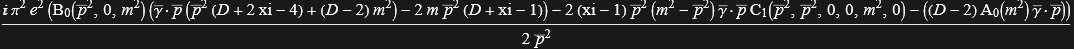
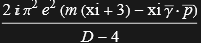

In [54]:


(* 2. Escribir la Amplitud estrictamente en D Dimensiones *)
(* GAD = Gamma D-dimensional, GSD = Slash D-dimensional *)
(* FAD = Denominadores de propagadores D-dimensionales *)
ampSigma = (-I * e * GAD[mu]) . (I * (GSD[p - k] + m) * FAD[{p - k, m}]) . (-I * e * GAD[nu]) * PropagadorFoton[k, mu, nu, xi];

(* 3. Calcular la Integral a 1-Loop en D dimensiones *)
loopResult = OneLoop[k, ampSigma] // Simplify;

(* 4. Extraer el Polo Ultravioleta (Divergencia UV) *)
divergentUV = PaVeUVPart[loopResult] // Simplify;

(* 5. Mostrar Resultados *)
Print["==============================================="];
Print[" AUTOENERGÍA DEL ELECTRÓN A 1-LOOP "];
Print["==============================================="];

Print["Resultado Completo (Finito + Divergente):"];
TraditionalForm[loopResult]

Print["Parte Divergente (Polo UV para Renormalizar):"];
TraditionalForm[divergentUV]

Contra-términos ($\delta Z_2$ y $\delta m$)

 RENORMALIZACIO'N: EXTRACCIO'N DE CONTRA-TE'RMINOS 
1. Constante de Funcio'n de Onda (dZ2):
2. Constante de Masa (dm):
3. Comprobacio'n (Divergencia + CT = 0):


FormBox["0", TraditionalForm]
FormBox[FractionBox[RowBox[{"2", " ", SuperscriptBox["π", "2"], " ", 

 
>         SuperscriptBox["e", "2"], " ", "m", " ", 

 
>         RowBox[{"(", RowBox[{"xi", "+", "3"}], ")"}]}], RowBox[{"D", "-", "4"}]], 

 
>      TraditionalForm]

FormBox[RowBox[{"-", FractionBox[RowBox[{"2", " ", "", " ", 

 
>           SuperscriptBox["π", "2"], " ", SuperscriptBox["e", "2"], " ", "xi", " ", 

 
>           RowBox[{OverscriptBox["γ", "_"], "·", 

 
>             FormBox[OverscriptBox[FormBox["p", TraditionalForm], "_"],\
 
>    TraditionalForm]}\
]}], RowBox[{"D", "-", "4"}]]}], TraditionalForm]
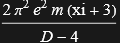
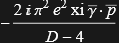

In [78]:

(* 2. Recuperamos la divergencia de la Autoenergía (Semana 4) *)
sigmaUV = divergentUV;

(* 3. Definición del Esquema de Renormalización (MS) *)
(* Queremos que el contra-término (CT) cancele exactamente a sigmaUV *)
(* Por lo tanto: CT + sigmaUV = 0  =>  CT = - sigmaUV *)
CT = - sigmaUV;

(* 4. Extracción de las Constantes de Renormalización dZ2 y dm *)
(* Sabemos teóricamente que el vértice del contra-término es: i*(dZ2*\not{p} - dm) *)
(* Usamos el comando 'Coefficient' de Wolfram para extraer los valores *)

(* Extraemos dZ2 (el coeficiente que multiplica a GSD[p]) y despejamos la 'I' *)
dZ2 = Simplify[ Coefficient[CT, GSD[p]] / I ];

(* Extraemos dm (el coeficiente que multiplica a 'm'), y despejamos la 'I' *)
dm = Simplify[ - Coefficient[CT, m] * m / I ];

(* 5. Prueba de Fuego: Comprobación de la cancelación *)
sumaTotal = Simplify[sigmaUV + I*(dZ2 * GSD[p] - dm)];

(* 6. Impresión de Resultados *)
Print["==============================================="];
Print[" RENORMALIZACIÓN: EXTRACCIÓN DE CONTRA-TÉRMINOS "];
Print["==============================================="];
Print["1. Constante de Función de Onda (dZ2):"];
TraditionalForm[dZ2]

Print["2. Constante de Masa (dm):"];
TraditionalForm[dm]

Print["3. Comprobación (Divergencia + CT = 0):"];
TraditionalForm[sumaTotal]

Polarización del Vacío


 POLARIZACIO'N DEL VACI'O A 1-LOOP 
Resultado Completo (Finito + Divergente):
Parte Divergente UV (Notar la estructura tensorial):


FormBox[FractionBox[RowBox[{"2", " ", SuperscriptBox["π", "2"], " ", 

 
>         SuperscriptBox["e", "2"], " ", 

 
>         RowBox[{"(", RowBox[{RowBox[{SuperscriptBox[FormBox[OverscriptBox[

 
>                  FormBox["q", TraditionalForm], "_"], TraditionalForm], 2], " ", 

 
>               SuperscriptBox[RowBox[{OverscriptBox["g", "_"]}], 

 
>                RowBox[{FormBox[FormBox["mu", TraditionalForm], TraditionalForm], 

 
>                  FormBox[FormBox["nu", TraditionalForm], TraditionalForm]}]]}], "-", 

 
>             RowBox[{SuperscriptBox[RowBox[{FormBox[OverscriptBox[FormBox["q", 

 
>                     TraditionalForm], "_"], TraditionalForm]}], 

 
>                FormBox[FormBox["mu", TraditionalForm], TraditionalForm]], " ", 

 
>               SuperscriptBox[RowBox[{FormBox[OverscriptBox[FormBox["q", 

 
>                     TraditionalForm], "_"], TraditionalForm]}], 

 
>                FormBox[FormBox["nu", TraditionalForm], TraditionalForm]]}]}], ")"}], 

 
>         " ", RowBox[{"(", RowBox[{RowBox[{RowBox[{"(", 

 
>                 RowBox[{RowBox[{RowBox[{"(", RowBox[{"D", "-", "2"}], ")"}], " ", 

 
>                     SuperscriptBox[FormBox[OverscriptBox[FormBox["q", 

 
>                         TraditionalForm], "_"], TraditionalForm], 2]}], "+", 

 
>                   RowBox[{"4", " ", SuperscriptBox["m", "2"]}]}], ")"}], " ", 

 
>               FormBox[TagBox[FormBox[RowBox[{SubscriptBox["\"B\"", "\"0\""], "(", 

 
>                    RowBox[{SuperscriptBox[FormBox[OverscriptBox[

 
>                         FormBox["q", TraditionalForm], "_"], TraditionalForm],\
 
>    2]\
, ",", SuperscriptBox["m", "2"], ",", SuperscriptBox["m", "2"]}], ")"}], 

 
>                  TraditionalForm], HoldForm], TraditionalForm]}], "-", 

 
>             RowBox[{"2", " ", RowBox[{"(", RowBox[{"D", "-", "2"}], ")"}], " ", 

 
>               FormBox[TagBox[FormBox[RowBox[{SubscriptBox["\"A\"", "\"0\""], "(", 

 
>                    SuperscriptBox["m", "2"], ")"}], TraditionalForm], HoldForm], 

 
>                TraditionalForm]}]}], ")"}]}], 

 
>       RowBox[{RowBox[{"(", RowBox[{"D", "-", "1"}], ")"}], " ", 

 
>         SuperscriptBox[FormBox[OverscriptBox[FormBox["q", TraditionalForm], "_"], 

 
>           TraditionalForm], 2]}]], TraditionalForm]

FormBox[FractionBox[RowBox[{"8", " ", SuperscriptBox["π", "2"], " ", 

 
>         SuperscriptBox["e", "2"], " ", 

 
>         RowBox[{"(", RowBox[{RowBox[{SuperscriptBox[RowBox[{FormBox[

 
>                   OverscriptBox[FormBox["q", TraditionalForm], "_"], 

 
>                   TraditionalForm]}], 

 
>                FormBox[FormBox["mu", TraditionalForm], TraditionalForm]], " ", 

 
>               SuperscriptBox[RowBox[{FormBox[OverscriptBox[FormBox["q", 

 
>                     TraditionalForm], "_"], TraditionalForm]}], 

 
>                FormBox[FormBox["nu", TraditionalForm], TraditionalForm]]}], "-", 

 
>             RowBox[{SuperscriptBox[FormBox[OverscriptBox[FormBox["q", 

 
>                   TraditionalForm], "_"], TraditionalForm], 2], " ", 

 
>               SuperscriptBox[RowBox[{OverscriptBox["g", "_"]}], 

 
>                RowBox[{FormBox[FormBox["mu", TraditionalForm], TraditionalForm], 

 
>                  FormBox[FormBox["nu", TraditionalForm], TraditionalForm]}]]}]}],\
 
>    ")"}]}\
], RowBox[{RowBox[{"(", RowBox[{"D", "-", "4"}], ")"}], " ", 

 
>         RowBox[{"(", RowBox[{"D", "-", "1"}], ")"}]}]], TraditionalForm]
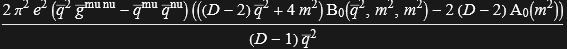
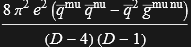

In [99]:


(* 2. Definimos la Amplitud de la Polarización del Vacío *)
(* q = momento del fotón externo, k = momento corriendo en el bucle *)
(* OJO: Llevamos un signo (-) global por ser un bucle cerrado de fermiones *)
(* La traza de Dirac aparece porque cerramos el ciclo fermiónico sobre sí mismo *)

amp = - I * e^2 * DiracTrace[ GAD[mu] . (GSD[k] + m) . GAD[nu] . (GSD[k + q] + m) ] * FAD[{k, m}, {k + q, m}];

(* 3. Calcular la Integral a 1-Loop *)
(* OneLoop realiza la integración D-dimensional y maneja la traza *)
loopResult = OneLoop[k, amp] // Simplify;

(* 4. Extraer el Polo Ultravioleta (Divergencia UV) *)
divergentUV = PaVeUVPart[loopResult] // Simplify;

(* 5. Imprimir Resultados *)
Print["==============================================="];
Print[" POLARIZACIÓN DEL VACÍO A 1-LOOP "];
Print["==============================================="];

Print["Resultado Completo (Finito + Divergente):"];
TraditionalForm[loopResult]

Print["Parte Divergente UV (Notar la estructura tensorial):"];
TraditionalForm[divergentUV]

# Renormalización

 RENORMALIZACIO'N: CONTRA-TE'RMINO DEL FOTO'N (dZ3) 
Constante de Renormalizacio'n de Funcio'n de Onda del Foto'n (dZ3):


FormBox[FractionBox[RowBox[{"8", " ", "", " ", SuperscriptBox["π", "2"], " ", 

 
>         SuperscriptBox["e", "2"]}], RowBox[{SuperscriptBox["D", "2"], "-", 

 
>         RowBox[{"5", " ", "D"}], "+", "4"}]], TraditionalForm]
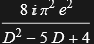

In [123]:

(* 2. Recuperar la divergencia de la Polarización del Vacío (Semana 6) *)
amp = - I * e^2 * DiracTrace[ GAD[mu] . (GSD[k] + m) . GAD[nu] . (GSD[k + q] + m) ] * FAD[{k, m}, {k + q, m}];
piUV = PaVeUVPart[OneLoop[k, amp]] // Simplify;

(* 3. El Truco de Proyección Escalar *)
(* Contraemos los índices mu y nu del tensor piUV con la métrica g_{mu,nu} *)
piUVEscalar = Contract[piUV * MetricTensor[mu, nu]] // Simplify;

(* 4. Extracción del Contra-término dZ3 *)
(* Sabemos teóricamente que el vértice del contra-término es: CT_tensor = -I * dZ3 * (q^2 g_munu - q_mu q_nu) *)
(* Al contraer CT_tensor con g_munu obtenemos teóricamente: CT_escalar = -I * dZ3 * q^2 * (D - 1) *)
(* En el Esquema MS imponemos la cancelación: piUVEscalar + CT_escalar = 0 *)
(* Despejamos dZ3 igualando CT_escalar = - piUVEscalar *)

(* Definimos q^2 en sintaxis FeynCalc para poder dividir *)
qSquared = Pair[Momentum[q], Momentum[q]];

(* Despejamos dZ3 algebraicamente *)
dZ3 = Simplify[ piUVEscalar / (I * qSquared * (D - 1)) ];

(* 5. Mostrar Resultados *)
Print["==============================================="];
Print[" RENORMALIZACIÓN: CONTRA-TÉRMINO DEL FOTÓN (dZ3) "];
Print["==============================================="];
Print["Constante de Renormalización de Función de Onda del Fotón (dZ3):"];
TraditionalForm[dZ3]

# Corrección de Vértice.

 CORRECCIO'N DE VE'RTICE Y CONTRA-TE'RMINO (dZ1) 
1. Divergencia UV del Ve'rtice:
2. Constante de Renormalizacio'n (dZ1):


FormBox[FractionBox[RowBox[{"2", " ", "", " ", SuperscriptBox["π", "2"], " ", 

 
>         SuperscriptBox["e", "3"], " ", "xi", " ", 

 
>         SuperscriptBox[RowBox[{OverscriptBox["γ", "_"]}], 

 
>          FormBox[FormBox["mu", TraditionalForm], TraditionalForm]]}], 

 
>       RowBox[{"D", "-", "4"}]], TraditionalForm]

FormBox["0", TraditionalForm]
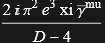

In [142]:

(* 2. Activamos el esquema t'Hooft-Veltman*)
FCSetDiracGammaScheme["BMHV"];

(* Propagador 4D temporal para armar la ecuación *)
PropagadorFoton4D[q_, rho_, sig_, xi_] := 
  -I * FAD[{q, 0}] * ( MT[rho, sig] - (1 - xi) * FV[q, rho] * FV[q, sig] * FAD[{q, 0}] );

(* 3. Escribimos la Amplitud con calibrado general *)
amp4D = (-I * e)^3 * GA[rho] . (GS[p2 - k] + m) . GA[mu] . (GS[p1 - k] + m) . GA[sig] * PropagadorFoton4D[k, rho, sig, xi] * I * FAD[{p1 - k, m}] * I * FAD[{p2 - k, m}];

(* 4. Promovemos a D-dimensiones como lo tenías *)
ampD = ChangeDimension[amp4D, D];

(* 5. Hacemos el cálculo a 1-loop (ahora que todo está estrictamente en D dimensiones) *)
vertexUV = PaVeUVPart[OneLoop[k, ampD]] // Simplify;

(* 6. Extraemos la constante dZ1 aislando la matriz GAD[mu] *)
dZ1 = Simplify[ Coefficient[vertexUV, GAD[mu]] / (I * e) ];

(* 7. Mostramos los Resultados *)
Print["==============================================="];
Print[" CORRECCIÓN DE VÉRTICE Y CONTRA-TÉRMINO (dZ1) "];
Print["==============================================="];

Print["1. Divergencia UV del Vértice:"];
TraditionalForm[vertexUV]

Print["2. Constante de Renormalización (dZ1):"];
TraditionalForm[dZ1]

# Auditoría de Consistencia Física (Identidad de Ward y Calibrado)
En esta sección el código verifica de manera automática que los cálculos anteriores no rompan la Invariancia de Gauge del Modelo Estándar, comprobando que $\delta Z_1 = \delta Z_2$ y que el resultado final sea independiente del parámetro de calibrado $\xi$.

In [159]:
(* ========================================================== *)
(* MÓDULO DE VERIFICACIÓN FÍSICA (IDENTIDAD DE WARD)          *)
(* ========================================================== *)

Print["==============================================="];
Print[" AUDITORÍA DEL MODELO Y CALIBRADO "];
Print["==============================================="];

(* 1. Comprobamos analíticamente si dZ1 y dZ2 son iguales a pesar del xi *)
(* Usamos Simplify para forzar a Mathematica a reducir fracciones algebraicas *)
diferenciaWard = Simplify[dZ1 - dZ2];

If[diferenciaWard === 0,
    Print["[ÉXITO] La Identidad de Ward se cumple (dZ1 = dZ2). Invariancia preservada."],
    Print["[ALERTA FATAL] Ruptura de Gauge detectada. Diferencia: "];
    TraditionalForm[diferenciaWard]
];

(* 2. Comprobamos si la física final depende del calibrado *)
(* Derivamos la diferencia respecto a xi. Si es 0, es independiente. *)
dependenciaXi = D[diferenciaWard, xi] // Simplify;

If[dependenciaXi === 0,
    Print["[ÉXITO] La relación de constantes es invariante de Gauge (independiente de xi)."],
    Print["[ERROR] El observable depende del calibrado. Revisa tus tensores."]
];

 AUDITORI'A DEL MODELO Y CALIBRADO 
[E'XITO] La Identidad de Ward se cumple (dZ1 = dZ2). Invariancia preservada.
[E'XITO] La relacio'n de constantes es invariante de Gauge (independiente de\
 
>   xi).


## Extensión del sector oscuro.

FeynCalc is already loaded! If you are trying to reload FeynCalc or load\
 
>   FeynArts, TARCER, PHI, FeynHelpers or any other add-on, please restart\
 
>   the kernel.
Divergencia UV (BSM):


$Aborted
FormBox[RowBox[{"-", FractionBox[RowBox[{"", " ", SuperscriptBox["π", "2"], " ", 

 
>           SuperscriptBox["e", "2"], " ", SuperscriptBox["eps", "2"], " ", 

 
>           RowBox[{"(", RowBox[{RowBox[{RowBox[{"(", 

 
>                   RowBox[{SuperscriptBox[FormBox[OverscriptBox[FormBox["p", 

 
>                         TraditionalForm], "_"], TraditionalForm], 2], "-", 

 
>                     RowBox[{"3", " ", SuperscriptBox["m", "2"]}]}], ")"}], " ", 

 
>                 RowBox[{OverscriptBox["γ", "_"], "·", 

 
>                   FormBox[OverscriptBox[FormBox["p", TraditionalForm], "_"], 

 
>                    TraditionalForm]}]}], "+", 

 
>               RowBox[{"2", " ", "m", " ", 

 
>                 RowBox[{"(", RowBox[{SuperscriptBox["m", "2"], "-", 

 
>                     RowBox[{"3", " ", SuperscriptBox["mDark", "2"]}]}], ")"}]}]}],\
 
>    ")"}]\
}], RowBox[{RowBox[{"(", RowBox[{"D", "-", "4"}], ")"}], " ", 

 
>           SuperscriptBox["mDark", "2"]}]]}], TraditionalForm]
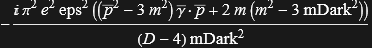

In [110]:
(* ========================================================== *)
(* SECTOR OSCURO: AUTOENERGÍA CON FOTÓN MASIVO A'             *)
(* ========================================================== *)
Clear["Global`*"];
<< FeynCalc`
FCSetDiracGammaScheme["BMHV"];

(* Definimos las nuevas variables simbólicas *)
(* eps = parámetro de mezcla, mDark = masa del fotón oscuro *)
DataType[eps, FCNSymbol] = True;
DataType[mDark, FCNSymbol] = True;

(* 1. Propagador del Fotón Oscuro (Masivo / Proca) *)
PropagadorDark[q_, mu_, nu_] := -I * FAD[{q, mDark}] * (MTD[mu, nu] - FVD[q, mu]*FVD[q, nu]/mDark^2);

(* 2. Amplitud de la Autoenergía BSM *)
ampDark = (-I * eps * e * GAD[mu]) . (I * (GSD[p - k] + m) * FAD[{p - k, m}]) . (-I * eps * e * GAD[nu]) * PropagadorDark[k, mu, nu];

(* 3. Extracción del Polo UV *)
uvDark = PaVeUVPart[OneLoop[k, ampDark]] // Simplify;

(* 4. Extracción de los nuevos Contra-términos *)
dZ2Dark = Simplify[ Coefficient[uvDark, GSD[p]] / I ];
dmDark = Simplify[ Coefficient[uvDark, m] / I ];

Print["Divergencia UV (BSM):"];
TraditionalForm[uvDark]